# Experiment 13

## Aim

To implement Mini-Batch Gradient Descent for Linear Regression and analyze how batch size affects training stability and performance.

## Theory

Mini-Batch Gradient Descent is an optimization algorithm that combines the advantages of Batch Gradient Descent and Stochastic Gradient Descent.

Instead of updating the weights using:

• Entire dataset (Batch GD)

or

• One sample (SGD)

Mini-Batch Gradient Descent updates the weights using a small batch of samples.

Weight Update Equation

w = w − α(dw)

Bias Update Equation

b = b − α(db)

where

α = Learning Rate

Batch Size determines the number of samples processed before updating the parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

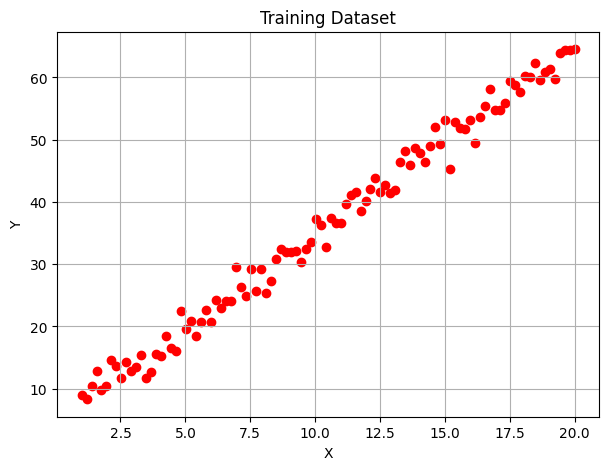

In [2]:
np.random.seed(42)

X = np.linspace(1,20,100)

Y = 3*X + 5 + np.random.randn(100)*2

plt.figure(figsize=(7,5))

plt.scatter(X,Y,color="red")

plt.title("Training Dataset")

plt.xlabel("X")

plt.ylabel("Y")

plt.grid(True)

plt.show()

In [3]:
w = 0
b = 0

learning_rate = 0.001

epochs = 100

batch_size = 10

loss_history = []

In [4]:
for epoch in range(epochs):

    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]

    for i in range(0, len(X), batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        Y_batch = Y_shuffled[i:i+batch_size]

        Y_pred = w * X_batch + b

        dw = (-2/len(X_batch)) * np.sum(X_batch * (Y_batch - Y_pred))
        db = (-2/len(X_batch)) * np.sum(Y_batch - Y_pred)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    loss = np.mean((Y - (w*X+b))**2)

    loss_history.append(loss)

print("Final Weight =", round(w,4))
print("Final Bias =", round(b,4))

Final Weight = 3.2319
Final Bias = 1.8045


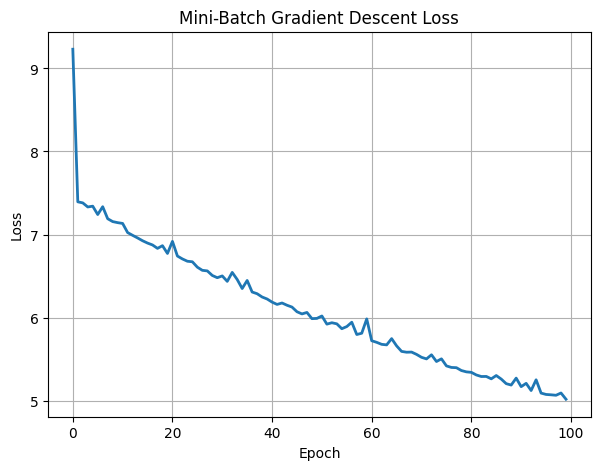

In [5]:
plt.figure(figsize=(7,5))

plt.plot(loss_history,
         linewidth=2)

plt.title("Mini-Batch Gradient Descent Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

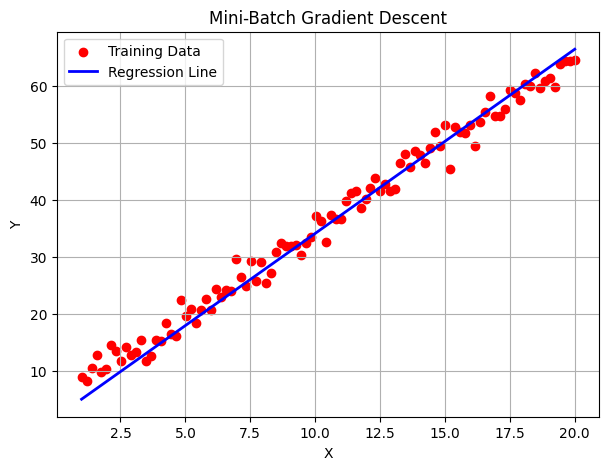

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(X,Y,
            color="red",
            label="Training Data")

plt.plot(X,
         w*X+b,
         color="blue",
         linewidth=2,
         label="Regression Line")

plt.title("Mini-Batch Gradient Descent")

plt.xlabel("X")

plt.ylabel("Y")

plt.legend()

plt.grid(True)

plt.show()

In [7]:
batch_sizes = [1,10,20,50,100]

training_type = [

    "SGD",
    "Mini-Batch",
    "Mini-Batch",
    "Mini-Batch",
    "Batch GD"

]

for b,t in zip(batch_sizes,training_type):

    print("Batch Size =",b," --> ",t)

Batch Size = 1  -->  SGD
Batch Size = 10  -->  Mini-Batch
Batch Size = 20  -->  Mini-Batch
Batch Size = 50  -->  Mini-Batch
Batch Size = 100  -->  Batch GD


            Start

              │

              ▼

      Initialize w, b

              │

              ▼

      Divide Dataset into
        Small Batches

              │

              ▼

      Select One Batch

              │

              ▼

      Compute Prediction

              │

              ▼

      Compute Loss

              │

              ▼

      Compute Gradients

              │

              ▼

      Update Weights

              │

              ▼

     More Batches Left?

         │         │

        Yes        No

         │         │

         └─────────┘

              ▼

        Next Epoch

              │

             Stop